In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import torch 
import torch.nn as nn 
import torch.optim as optim 
from pathlib import Path 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_regression

In [4]:
session_test_path = "/Users/thomasbush/Downloads/shared WithTWB/m001_s001_cricket.xlsx"
start_times = pd.read_excel("/Users/thomasbush/Downloads/shared WithTWB/startTimes.xlsx")
data = pd.read_excel(session_test_path)

In [5]:
data.head()

,timestamp,dist_head,dist,dist_change,facing_angle,rel_bearing,rel_angle_target,angle_head_body_axis,angle_head_body_l,angle_head_body_r,...,tangential_vel,nose_tail_distance,forepawL_tail_distance,forepawR_tail_distance,forepaw_target_distance,angle_head_body_speed,dist_head_scaled,dist_scaled,dist_change_scaled,omega_theta_trunk
0,1587.446375,NaN,NaN,NaN,NaN,NaN,NaN,-0.935600,24.641381,-25.475310,...,NaN,76.338229,48.452654,57.572613,NaN,NaN,NaN,NaN,NaN,NaN
1,1587.462425,NaN,NaN,NaN,NaN,NaN,NaN,-0.750100,24.411168,-26.834251,...,NaN,77.085023,50.018734,56.731788,NaN,NaN,NaN,NaN,NaN,NaN
2,1587.478450,NaN,NaN,NaN,NaN,NaN,NaN,-1.347490,22.114337,-26.013075,...,NaN,76.644663,53.220069,54.814461,NaN,-55.036871,NaN,NaN,NaN,63.571650
3,1587.494475,NaN,NaN,NaN,NaN,NaN,NaN,-2.416442,19.179621,-25.239463,...,NaN,75.590964,57.099248,52.399952,NaN,1.298267,NaN,NaN,NaN,67.032779
4,1587.510525,NaN,NaN,NaN,NaN,NaN,NaN,-3.682747,17.462795,-29.140221,...,NaN,74.538408,60.360097,50.182172,NaN,1.748303,NaN,NaN,NaN,33.442541


In [6]:
first_valid_index = data['dist_head'].first_valid_index()
print("First index where dist_head is not NaN:", first_valid_index)
data_before_start = data.loc[:first_valid_index-1]

# Drop only columns where all values are NaN; tolerate columns with some (but not all) NaNs
data_before_start = data_before_start.dropna(axis=1, how='all')

First index where dist_head is not NaN: 19464


In [7]:
data_before_start.head()

,timestamp,angle_head_body_axis,angle_head_body_l,angle_head_body_r,height,height_scaled,ori_allBody,ori_trunk,ori_head,head_acc,rigidbody_acc,speed_head_fwd,head_speed,trunk_speed,nose_tail_distance,forepawL_tail_distance,forepawR_tail_distance,angle_head_body_speed,omega_theta_trunk
0,1587.446375,-0.935600,24.641381,-25.475310,14.079084,0.193491,-78.315639,-77.944298,-78.631933,220.705641,307.652998,72.126632,76.825632,71.217742,76.338229,48.452654,57.572613,NaN,NaN
1,1587.462425,-0.750100,24.411168,-26.834251,13.984838,0.192187,-77.772873,-77.825353,-78.795294,220.705641,307.652998,85.708557,72.561708,95.854500,77.085023,50.018734,56.731788,NaN,NaN
2,1587.478450,-1.347490,22.114337,-26.013075,13.756209,0.189023,-77.264654,-77.012126,-79.992833,220.705641,307.652998,90.820353,99.333731,106.616066,76.644663,53.220069,54.814461,-55.036871,63.571650
3,1587.494475,-2.416442,19.179621,-25.239463,13.467453,0.185028,-76.807672,-75.915779,-81.700636,220.705641,307.652998,89.847875,97.922032,106.239161,75.590964,57.099248,52.399952,1.298267,67.032779
4,1587.510525,-3.682747,17.462795,-29.140221,13.209066,0.181453,-76.332136,-74.892533,-83.664558,227.942526,310.316865,87.421985,88.109641,98.113465,74.538408,60.360097,50.182172,1.748303,33.442541


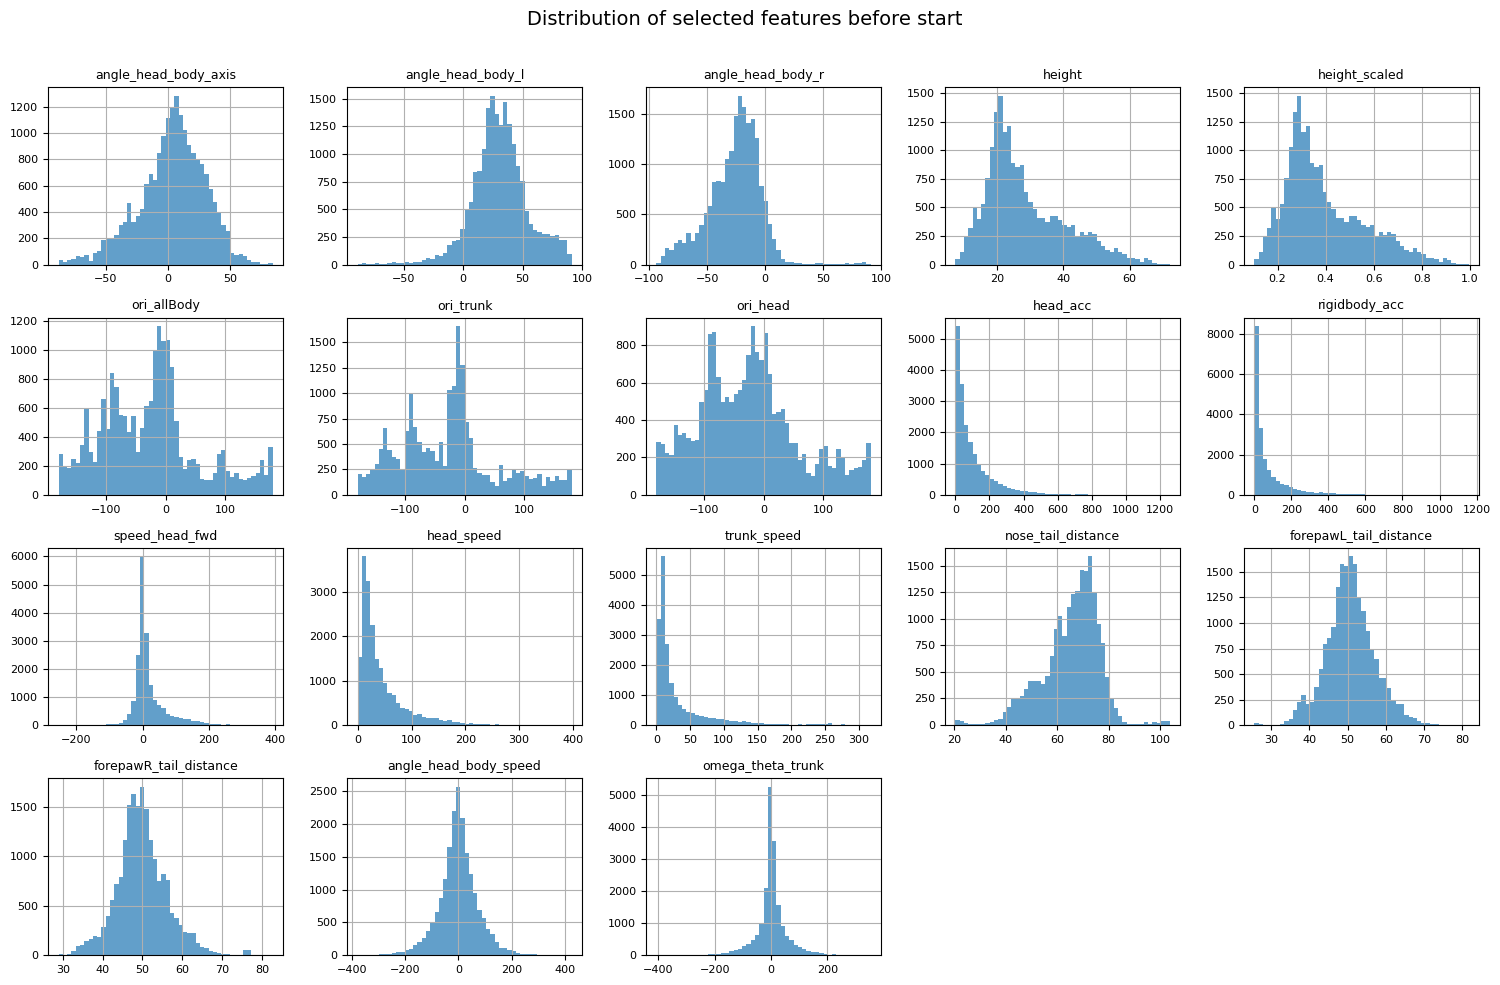

In [8]:
# Visualize distributions of features before start, skipping non-numeric columns and those with insufficient data
numeric_data = data_before_start.select_dtypes(include=[np.number])

# Drop 'timestamp' column if present for plotting
numeric_data = numeric_data.drop(columns=['timestamp'], errors='ignore')

# Drop columns with too few non-null values to avoid empty plots
min_non_nan = max(5, int(0.05 * len(numeric_data)))  # at least 5 or 5% of data
filtered_numeric = numeric_data.dropna(axis=1, thresh=min_non_nan)

# If there are too many columns, limit the plots for readability
max_columns = 20
cols_to_plot = filtered_numeric.columns[:max_columns]
plot_data = filtered_numeric[cols_to_plot]

n_cols = 5
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    plot_data[col].hist(ax=ax, bins=50, color='tab:blue', alpha=0.7)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])  # Remove empty subplots

fig.suptitle('Distribution of selected features before start', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [9]:
data_before_start.columns

angular_features = ['angle_head_body_axis', 'angle_head_body_l', 'angle_head_body_r', 'ori_allBody', 'ori_trunk', 'ori_head', "timestamp"]

# Normalize all non-angular numeric features, leave angular features untouched
def normalize_feature(feature):
    return (feature - feature.mean()) / feature.std()

# Select non-angular numeric columns for normalization
cols_to_normalize = [
    col for col in data_before_start.select_dtypes(include=[np.number]).columns
    if col not in angular_features
]

data_before_start[cols_to_normalize] = data_before_start[cols_to_normalize].apply(normalize_feature)

data_before_start.head()



,timestamp,angle_head_body_axis,angle_head_body_l,angle_head_body_r,height,height_scaled,ori_allBody,ori_trunk,ori_head,head_acc,rigidbody_acc,speed_head_fwd,head_speed,trunk_speed,nose_tail_distance,forepawL_tail_distance,forepawR_tail_distance,angle_head_body_speed,omega_theta_trunk
0,1587.446375,-0.935600,24.641381,-25.475310,-1.215840,-1.215840,-78.315639,-77.944298,-78.631933,1.014990,2.274591,1.034114,0.719869,0.826931,0.984247,-0.358308,1.175720,NaN,NaN
1,1587.462425,-0.750100,24.411168,-26.834251,-1.223748,-1.223748,-77.772873,-77.825353,-78.795294,1.014990,2.274591,1.299927,0.626736,1.357824,1.051667,-0.112049,1.046517,NaN,NaN
2,1587.478450,-1.347490,22.114337,-26.013075,-1.242931,-1.242931,-77.264654,-77.012126,-79.992833,1.014990,2.274591,1.399970,1.211491,1.589723,1.011912,0.391346,0.751896,-0.728908,1.070387
3,1587.494475,-2.416442,19.179621,-25.239463,-1.267159,-1.267159,-76.807672,-75.915779,-81.700636,1.014990,2.274591,1.380937,1.180657,1.581601,0.916785,1.001329,0.380877,0.023612,1.128925
4,1587.510525,-3.682747,17.462795,-29.140221,-1.288839,-1.288839,-76.332136,-74.892533,-83.664558,1.076016,2.300306,1.333460,0.966334,1.406502,0.821761,1.514083,0.040088,0.029623,0.560813


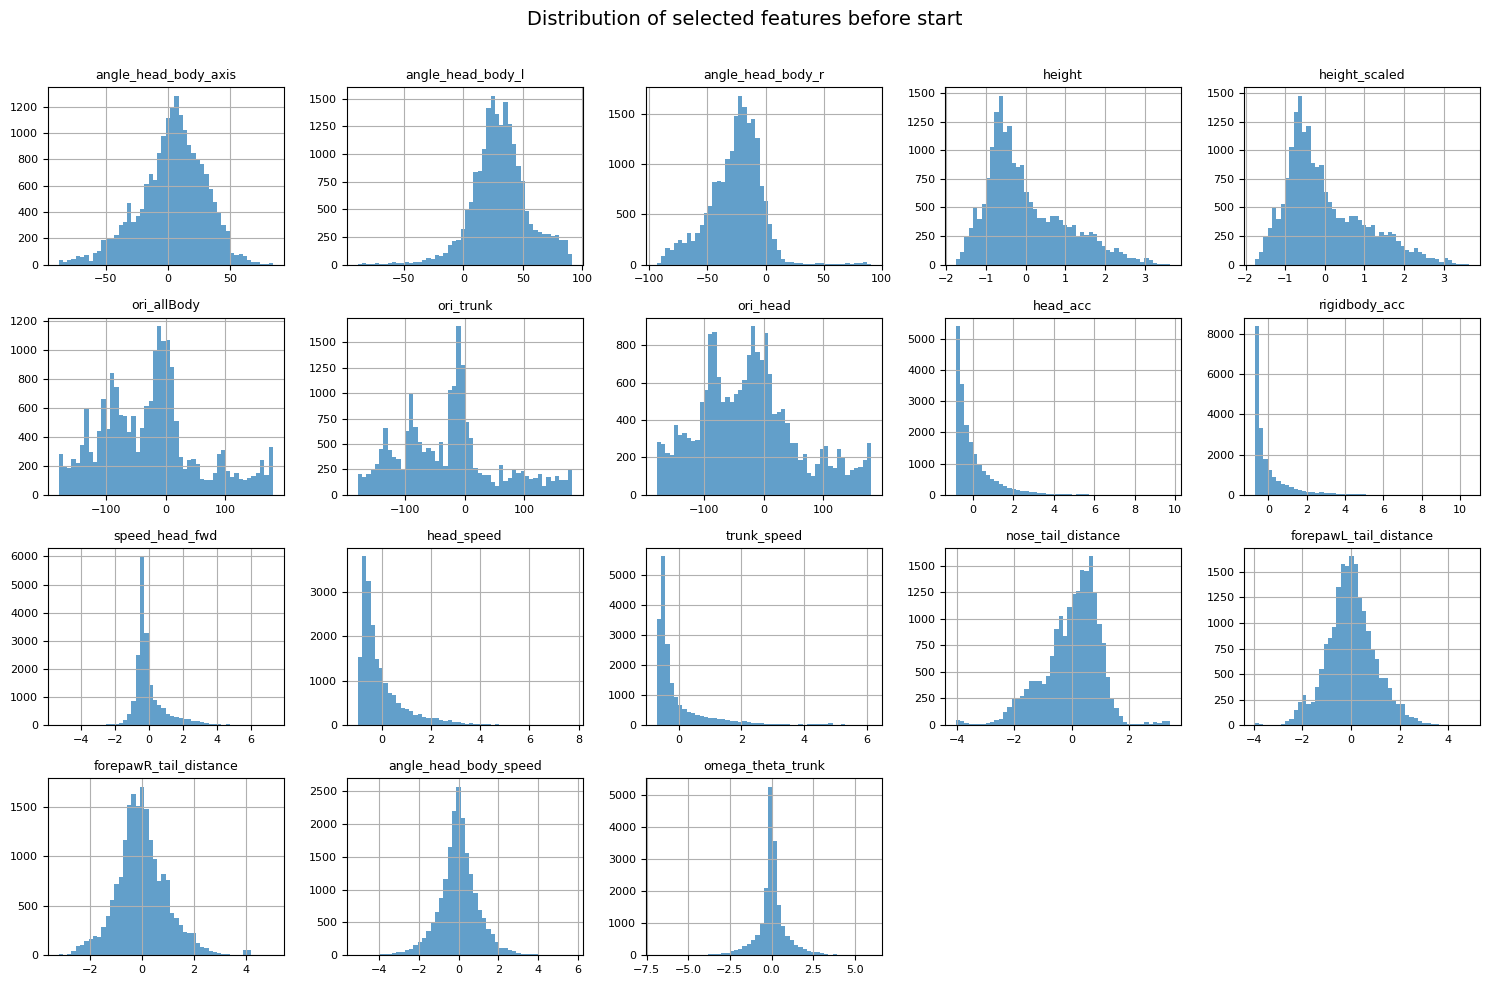

In [10]:
# now we check the distrbution of the normalized features: 
numeric_data = data_before_start.select_dtypes(include=[np.number])

# Drop 'timestamp' column if present for plotting
numeric_data = numeric_data.drop(columns=['timestamp'], errors='ignore')

# Drop columns with too few non-null values to avoid empty plots
min_non_nan = max(5, int(0.05 * len(numeric_data)))  # at least 5 or 5% of data
filtered_numeric = numeric_data.dropna(axis=1, thresh=min_non_nan)

# If there are too many columns, limit the plots for readability
max_columns = 20
cols_to_plot = filtered_numeric.columns[:max_columns]
plot_data = filtered_numeric[cols_to_plot]

n_cols = 5
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    plot_data[col].hist(ax=ax, bins=50, color='tab:blue', alpha=0.7)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])  # Remove empty subplots

fig.suptitle('Distribution of selected features before start', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [11]:
# we now convert the angular features to sin and cos: 
angular_features = ['angle_head_body_axis', 'angle_head_body_l', 'angle_head_body_r', 'ori_allBody', 'ori_trunk', 'ori_head']
# Convert all angular features in `angular_features` into their sine and cosine representations
for theta_col in angular_features:
    if theta_col in data_before_start.columns:
        theta_rad = np.deg2rad(data_before_start[theta_col])
        data_before_start[f"{theta_col}_sin"] = np.sin(theta_rad)
        data_before_start[f"{theta_col}_cos"] = np.cos(theta_rad)

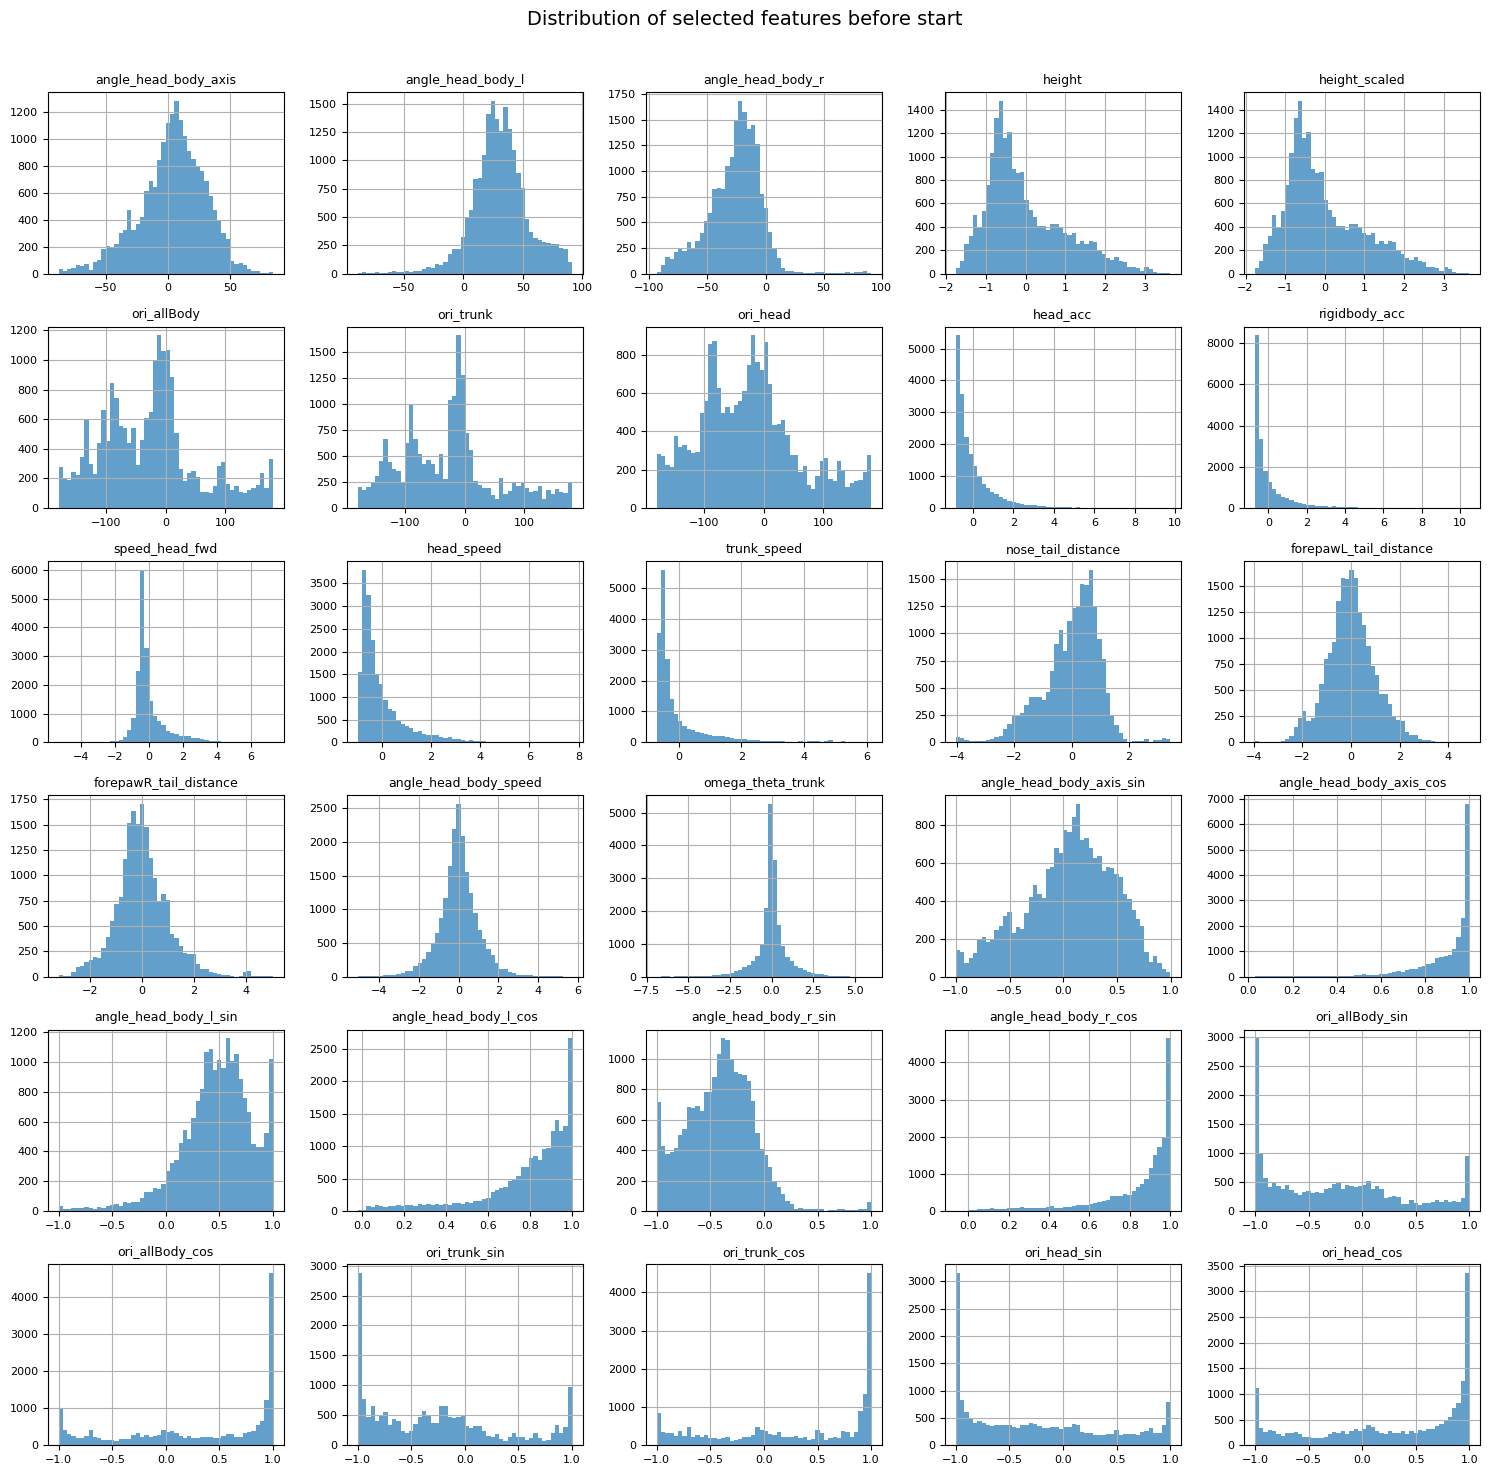

In [12]:
numeric_data = data_before_start.select_dtypes(include=[np.number])

# Drop 'timestamp' column if present for plotting
numeric_data = numeric_data.drop(columns=['timestamp'], errors='ignore')

# Drop columns with too few non-null values to avoid empty plots
min_non_nan = max(5, int(0.05 * len(numeric_data)))  # at least 5 or 5% of data
filtered_numeric = numeric_data.dropna(axis=1, thresh=min_non_nan)

# If there are too many columns, limit the plots for readability
max_columns = 50
cols_to_plot = filtered_numeric.columns[:max_columns]
plot_data = filtered_numeric[cols_to_plot]

n_cols = 5
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    plot_data[col].hist(ax=ax, bins=50, color='tab:blue', alpha=0.7)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])  # Remove empty subplots

fig.suptitle('Distribution of selected features before start', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [13]:
# now drop the orignal angular featues 
data_before_start = data_before_start.drop(columns=angular_features)
# now we check the distrbution of the normalized features: 
numeric_data = data_before_start.select_dtypes(include=[np.number])

# Drop 'timestamp' column if present for plotting
numeric_data = numeric_data.drop(columns=['timestamp'], errors='ignore')

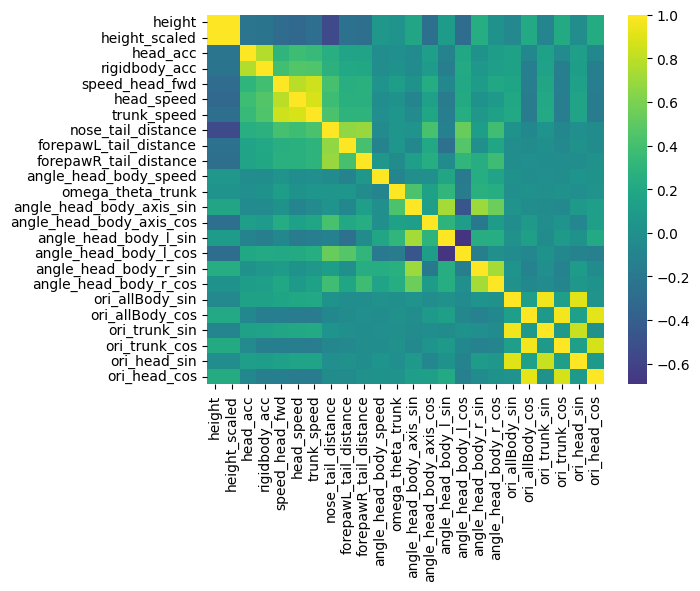

In [14]:
# now we can check the covariance matrix: 
sns.heatmap(numeric_data.corr(), cmap='viridis', center=0)
plt.show()

In [15]:
numeric_data.head()

,height,height_scaled,head_acc,rigidbody_acc,speed_head_fwd,head_speed,trunk_speed,nose_tail_distance,forepawL_tail_distance,forepawR_tail_distance,...,angle_head_body_l_sin,angle_head_body_l_cos,angle_head_body_r_sin,angle_head_body_r_cos,ori_allBody_sin,ori_allBody_cos,ori_trunk_sin,ori_trunk_cos,ori_head_sin,ori_head_cos
0,-1.215840,-1.215840,1.014990,2.274591,1.034114,0.719869,0.826931,0.984247,-0.358308,1.175720,...,0.416937,0.908935,-0.430122,0.902771,-0.979278,0.202520,-0.977945,0.208863,-0.980381,0.197111
1,-1.223748,-1.223748,1.014990,2.274591,1.299927,0.626736,1.357824,1.051667,-0.112049,1.046517,...,0.413282,0.910603,-0.451411,0.892316,-0.977316,0.211788,-0.977509,0.210892,-0.980939,0.194315
2,-1.242931,-1.242931,1.014990,2.274591,1.399970,1.211491,1.589723,1.011912,0.391346,0.751896,...,0.376456,0.926434,-0.438576,0.898694,-0.975399,0.220448,-0.974418,0.224745,-0.984786,0.173771
3,-1.267159,-1.267159,1.014990,2.274591,1.380937,1.180657,1.581601,0.916785,1.001329,0.380877,...,0.328531,0.944493,-0.426402,0.904534,-0.973609,0.228221,-0.969939,0.243348,-0.989527,0.144345
4,-1.288839,-1.288839,1.076016,2.300306,1.333460,0.966334,1.406502,0.821761,1.514083,0.040088,...,0.300086,0.953912,-0.486949,0.873431,-0.971682,0.236293,-0.965439,0.260630,-0.993893,0.110349


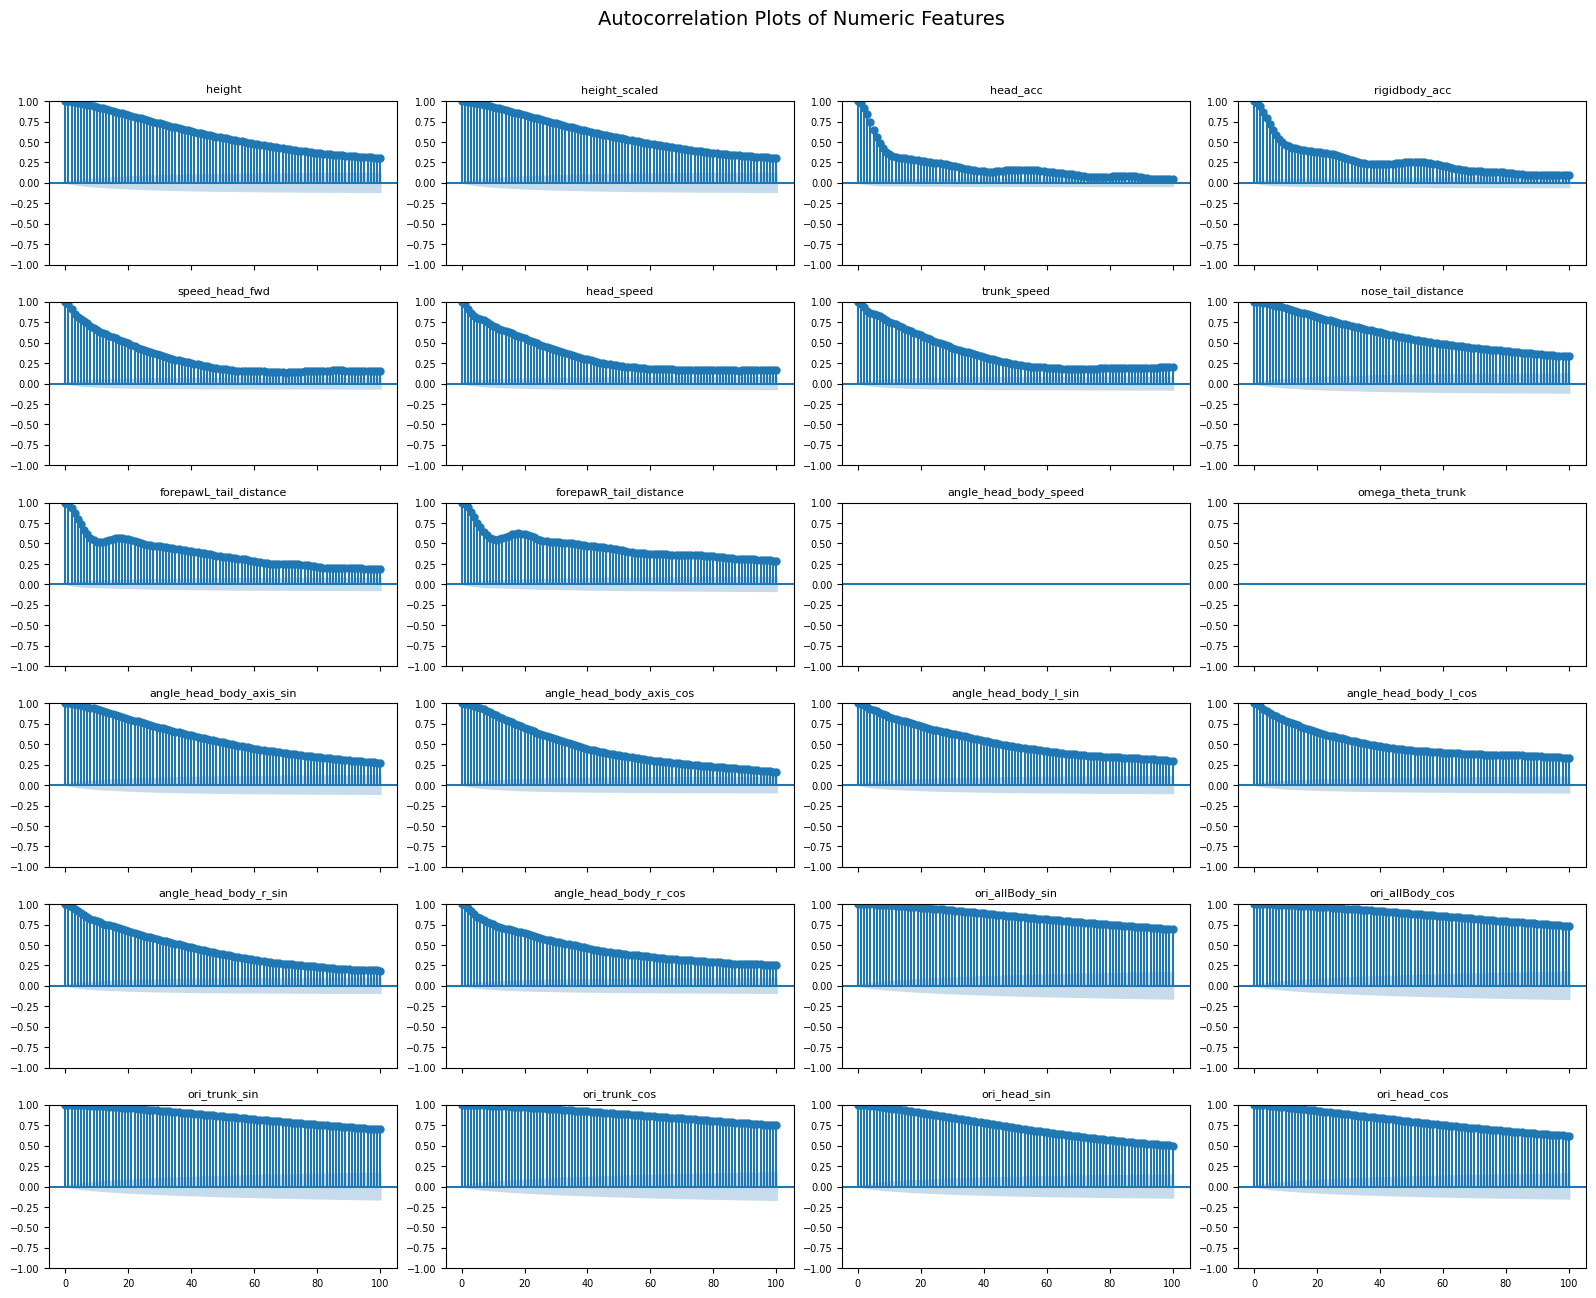

In [16]:
from statsmodels.graphics.tsaplots import plot_acf
features = numeric_data.columns
n_features = len(features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 2.2), sharex=True)
axes = axes.flatten()

for i, feat in enumerate(features):
    plot_acf(numeric_data[feat], lags=100, ax=axes[i])
    axes[i].set_title(feat, fontsize=8)
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

# Remove unused subplots, if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Autocorrelation Plots of Numeric Features', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



In [20]:
from statsmodels.tsa.stattools import ccf, acf

def decorrelation_lag(x, thres=0.2, max_lag = 200):
    a =acf(x, nlags=max_lag)
    idx =np.where(np.abs(a)<thres)[0]

    return idx[0] if len(idx) else max_lag

for feat in numeric_data.columns:
    print(feat, decorrelation_lag(numeric_data[feat]))


height 200
height_scaled 200
head_acc 32
rigidbody_acc 62
speed_head_fwd 47
head_speed 55
trunk_speed 59
nose_tail_distance 200
forepawL_tail_distance 84
forepawR_tail_distance 159
angle_head_body_speed 200
omega_theta_trunk 200
angle_head_body_axis_sin 128
angle_head_body_axis_cos 89
angle_head_body_l_sin 170
angle_head_body_l_cos 200
angle_head_body_r_sin 91
angle_head_body_r_cos 155
ori_allBody_sin 200
ori_allBody_cos 200
ori_trunk_sin 200
ori_trunk_cos 200
ori_head_sin 200
ori_head_cos 200


In [32]:
def make_windows(df, window_size=128, stride=1):
    X = df.values.astype(np.float32)
    windows=[]
    for i in range(0, len(X)-window_size + 1, stride):
        windows.append(X[i:i+window_size])
    return np.stack(windows)

T = 128
numeric_data_interp = numeric_data.interpolate(
    method="linear",
    limit_direction="both"
)

X = make_windows(numeric_data_interp, T, 1)

print(X.shape)

    

(19337, 128, 24)


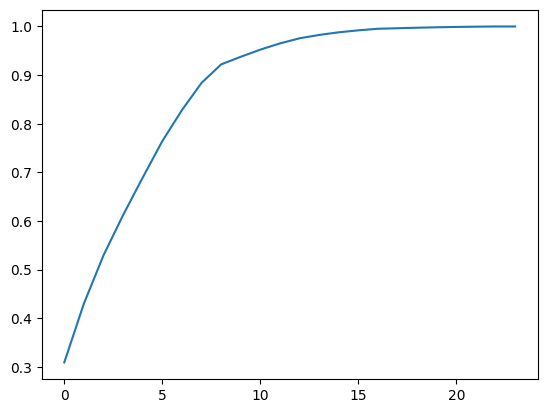

In [38]:
from sklearn.decomposition import PCA

X_frame = numeric_data_interp.values

pca = PCA()
Z = pca.fit_transform(X_frame)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.show()


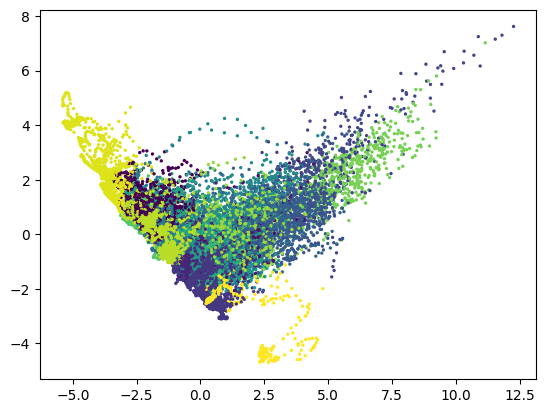

In [ ]:
from sklearn.cluster import KMeans

labels = KMeans(20).fit_predict(Z, )
plt.scatter(Z[:,0], Z[:,1], c=labels, s=2)
plt.show()


## Model building 

Models to consider + training loss: 

- Masked modelling (BERT): loss is to reconstruct the mask with a Huber loss 
- Next-step prediction casual 
Contrastive predictive coding (CPC, infoNCE): make representations predictive of the future while discriminating against negatives. Enc(X)->z_t + z_t+1r use infoNCE to classify tru future among negatives 

## Data Exploratory Analysis 

<Axes: >

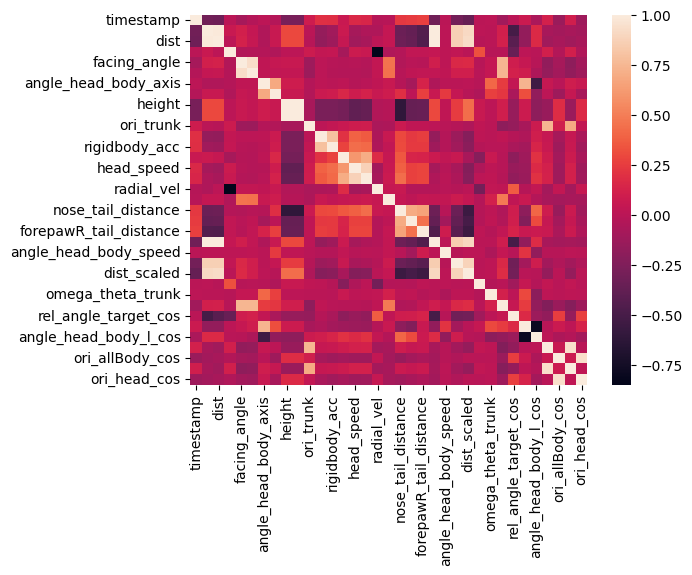

In [65]:
# Apply sin and cos transforms to angle features
angle_cols = [
    'acing_angle',
    'rel_angle_target',
    'angle_head_body_l',
    'ori_allBody',
    'ori_head'
]
for angle_col in angle_cols:
    if angle_col in data.columns:
        # Assuming angles are in degrees; convert to radians
        radians = np.deg2rad(data[angle_col])
        data[f'{angle_col}_sin'] = np.sin(radians)
        data[f'{angle_col}_cos'] = np.cos(radians)

# Create new DataFrame without the original angle columns, keeping only the sin/cos features and other columns
cols_to_keep = [col for col in data.columns if col not in angle_cols]
data_no_angle = data[cols_to_keep]

# Compute and plot correlation heatmap
sns.heatmap(data_no_angle.corr())



We check the distibution over time per for each feature:

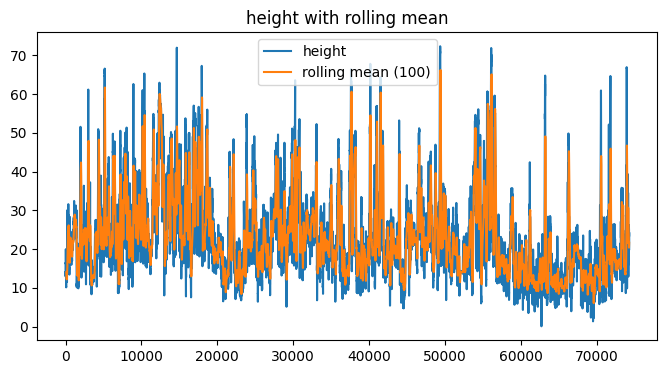

In [40]:
def plot_rolling_mean(df, column, window=60, ax=None):
    """
    Plots the original series and its rolling mean for a specified column in a DataFrame.

    Args:
        df (pd.DataFrame): The input data frame.
        column (str): Column name to plot.
        window (int): Rolling window size.
        ax (matplotlib.axes.Axes, optional): Axis to plot on.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    df[column].plot(ax=ax, title=f'{column} with rolling mean')
    df[column].rolling(window=window).mean().plot(ax=ax, label=f'rolling mean ({window})')
    ax.legend()
    plt.show()

# Example usage:
plot_rolling_mean(data, "height", window=100)

In [46]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import pandas as pd
import numpy as np

def plot_acf_for_column(df: pd.DataFrame, column: str, lags: int = 40, show_values: bool = True):
    """
    Plots the autocorrelation function (ACF) for a specified column in a pandas DataFrame.
    Optionally prints the autocorrelation values. The input series is normalized (zero mean, unit variance) before autocorrelation.

    Args:
        df (pd.DataFrame): Input DataFrame.
        column (str): Column name for which to plot ACF.
        lags (int): Number of lags to plot/check.
        show_values (bool): Whether to print the autocorrelation values.
    """
    series = df[column].dropna()
    # Normalize the series (zero mean, unit variance)
    normalized_series = (series - series.mean()) / series.std(ddof=0)
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_acf(normalized_series, lags=lags, ax=ax)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(f'Autocorrelation Plot for {column} (normalized)')
    plt.show()
    autocorr_values = acf(normalized_series, nlags=lags)
    if show_values:
        print(f"Autocorrelation values for '{column}' (normalized):", autocorr_values)
    return autocorr_values

# Example usage:
# plot_acf_for_column(data, 'height', lags=24)


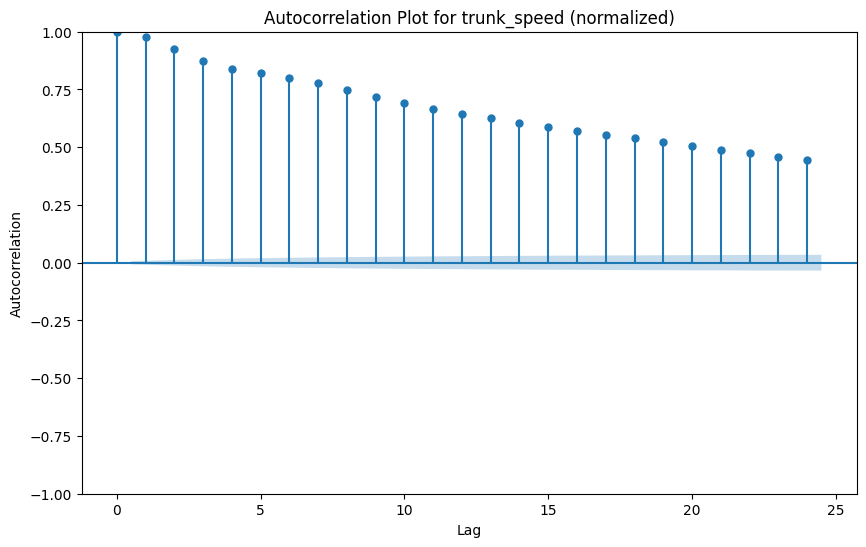

Autocorrelation values for 'trunk_speed' (normalized): [1.         0.97755686 0.9263824  0.87441756 0.83931276 0.81947497
 0.80169694 0.77671773 0.74687598 0.71734807 0.69086383 0.66707592
 0.64495857 0.62458107 0.60550472 0.58753343 0.57054218 0.5542137
 0.53799462 0.52151953 0.5049616  0.48880238 0.4733917  0.45860191
 0.44410698]


array([1.        , 0.97755686, 0.9263824 , 0.87441756, 0.83931276,
       0.81947497, 0.80169694, 0.77671773, 0.74687598, 0.71734807,
       0.69086383, 0.66707592, 0.64495857, 0.62458107, 0.60550472,
       0.58753343, 0.57054218, 0.5542137 , 0.53799462, 0.52151953,
       0.5049616 , 0.48880238, 0.4733917 , 0.45860191, 0.44410698])

In [51]:
plot_acf_for_column(data, 'trunk_speed', lags=24)

In [56]:
def compute_cross_correlation(data: pd.DataFrame, col1: str, col2: str, max_lag: int):
    """
    Computes and plots the cross-correlation between two columns in a DataFrame over a range of lags.

    Args:
        data (pd.DataFrame): The input DataFrame.
        col1 (str): The first column name.
        col2 (str): The second column name.
        max_lag (int): The maximum lag to compute cross-correlation for (from -max_lag to +max_lag).
    """
    val1 = data[col1].dropna().values
    val2 = data[col2].dropna().values

    # Ensure same length
    min_len = min(len(val1), len(val2))
    val1 = val1[:min_len]
    val2 = val2[:min_len]

    # Normalize to zero mean, unit variance
    val1_norm = (val1 - np.mean(val1)) / np.std(val1)
    val2_norm = (val2 - np.mean(val2)) / np.std(val2)

    lags = np.arange(-max_lag, max_lag + 1)
    cross_corr = []
    for lag in lags:
        if lag < 0:
            c = np.corrcoef(val1_norm[:lag], val2_norm[-lag:])[0, 1]
        elif lag > 0:
            c = np.corrcoef(val1_norm[lag:], val2_norm[:-lag])[0, 1]
        else:
            c = np.corrcoef(val1_norm, val2_norm)[0, 1]
        cross_corr.append(c)

    plt.figure(figsize=(10, 6))
    plt.plot(lags, cross_corr, marker='o')
    plt.title(f'Cross-Correlation between {col1} and {col2}')
    plt.xlabel('Lag')
    plt.ylabel('Correlation')
    plt.axhline(0, color='black', linestyle='--')
    plt.grid(ls=':', lw=2)
    plt.show()

    return lags, np.array(cross_corr)

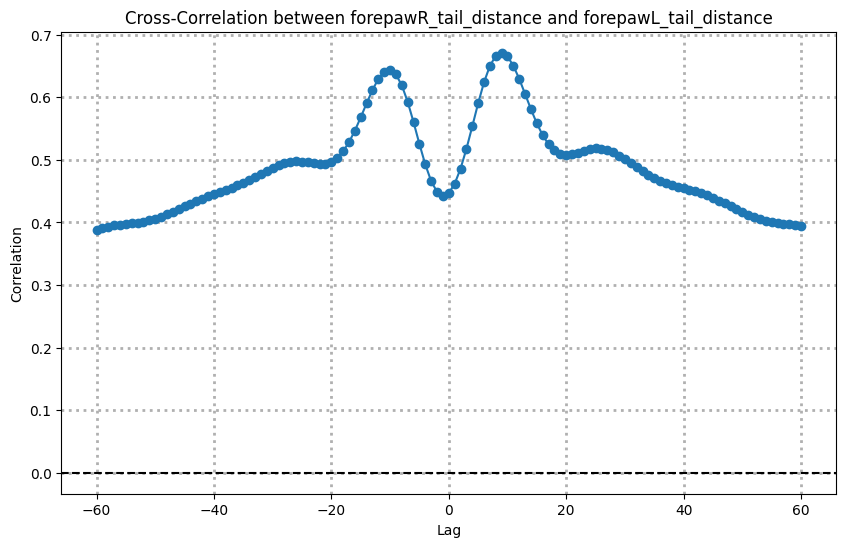

(array([-60, -59, -58, -57, -56, -55, -54, -53, -52, -51, -50, -49, -48,
        -47, -46, -45, -44, -43, -42, -41, -40, -39, -38, -37, -36, -35,
        -34, -33, -32, -31, -30, -29, -28, -27, -26, -25, -24, -23, -22,
        -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10,  -9,
         -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,
          5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,
         18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,
         31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,
         44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
         57,  58,  59,  60]),
 array([0.38795707, 0.39074904, 0.39317103, 0.3951772 , 0.39673458,
        0.39789262, 0.39883511, 0.39984511, 0.40123296, 0.40322392,
        0.40588919, 0.40916615, 0.41292217, 0.41700457, 0.42128091,
        0.42563371, 0.42994493, 0.43409286, 0.43799202, 0.44163492,
        0.4451035 , 0.44853053, 0.4520465

In [ ]:
compute_cross_correlation(data, "forepawR_tail_distance", "forepawL_tail_distance", 60)

## Create windows 

In [66]:

def robust_scale(s, eps=1e-12):
    med = s.median()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    denom = iqr if abs(iqr) > eps else s.std()
    denom = denom if abs(denom) > eps else 1.0
    return (s - med) / denom


def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


def winsorize(s, p=0.005):
    lo = s.quantile(p)
    hi = s.quantile(1 - p)
    return s.clip(lo, hi)


# ---------- CONFIG ----------

angle_cols = [
    "facing_angle",
    "rel_angle_target",
    "angle_head_body_axis",
    "angle_head_body_l",
    "angle_head_body_r",
    "ori_allBody",
    "ori_trunk",
    "ori_head",
]

log1p_nonneg = [
    "dist", "dist_head", "height", "height_scaled",
    "head_speed", "trunk_speed",
    "nose_tail_distance",
    "forepawL_tail_distance",
    "forepawR_tail_distance",
    "forepaw_target_distance",
    "dist_scaled", "dist_head_scaled",
]

signed_log = [
    "omega_theta_trunk",
    "head_acc",
    "rigidbody_acc",
    "tangential_vel",
]

# ---------- START CLEANING ----------

df = data.copy()

# Drop timestamp
if "timestamp" in df.columns:
    df = df.drop(columns="timestamp")

# Angles → sin/cos
for col in angle_cols:
    if col in df.columns:
        df[col + "_sin"] = np.sin(df[col])
        df[col + "_cos"] = np.cos(df[col])

df = df.drop(columns=[c for c in angle_cols if c in df.columns])

# Radial velocity → approach / retreat
if "radial_vel" in df.columns:
    rv = df["radial_vel"]
    df["radial_approach"] = np.clip(-rv, 0, None)
    df["radial_retreat"] = np.clip(rv, 0, None)
    df = df.drop(columns="radial_vel")

# Signed log on heavy-tailed signed vars
for col in signed_log:
    if col in df.columns:
        df[col] = signed_log1p(df[col])

# log1p on heavy-tailed NONNEGATIVE vars
for col in log1p_nonneg:
    if col in df.columns and (df[col] >= 0).all():
        df[col] = np.log1p(df[col])

# Winsorize numeric columns
for col in df.select_dtypes(include=np.number):
    df[col] = winsorize(df[col])

# Robust scale numeric columns
for col in df.select_dtypes(include=np.number):
    df[col] = robust_scale(df[col])

# Drop constant columns
df = df.loc[:, df.nunique() > 1]

data_clean = df

print("Cleaned shape:", data_clean.shape)
data_clean.head()


Cleaned shape: (74289, 39)


,dist_head,dist,dist_change,rel_bearing,height,height_scaled,head_acc,rigidbody_acc,speed_head_fwd,head_speed,...,facing_angle_sin,facing_angle_cos,angle_head_body_axis_sin,angle_head_body_axis_cos,angle_head_body_r_sin,angle_head_body_r_cos,ori_trunk_sin,ori_trunk_cos,radial_approach,radial_retreat
0,NaN,NaN,NaN,NaN,-0.639576,-0.551357,0.555949,0.885685,1.397709,0.727429,...,NaN,NaN,-0.564582,0.427238,-0.239401,0.664361,-0.384448,-0.584936,NaN,NaN
1,NaN,NaN,NaN,NaN,-0.650758,-0.559649,0.555949,0.885685,1.686054,0.654501,...,NaN,NaN,-0.477301,0.524848,-0.704149,-0.091661,-0.451284,-0.533825,NaN,NaN
2,NaN,NaN,NaN,NaN,-0.678179,-0.579801,0.555949,0.885685,1.794578,1.112396,...,NaN,NaN,-0.685128,0.164741,-0.547818,0.449308,-0.695060,-0.031018,NaN,NaN
3,NaN,NaN,NaN,NaN,-0.713426,-0.605329,0.555949,0.885685,1.773933,1.088251,...,NaN,NaN,-0.464225,-0.519844,-0.076780,0.701319,-0.337530,0.612795,NaN,NaN
4,NaN,NaN,NaN,NaN,-0.745567,-0.628245,0.573371,0.889664,1.722431,0.920425,...,NaN,NaN,0.370298,-0.596581,0.538707,-0.456630,0.356646,0.616895,NaN,NaN


<Axes: >

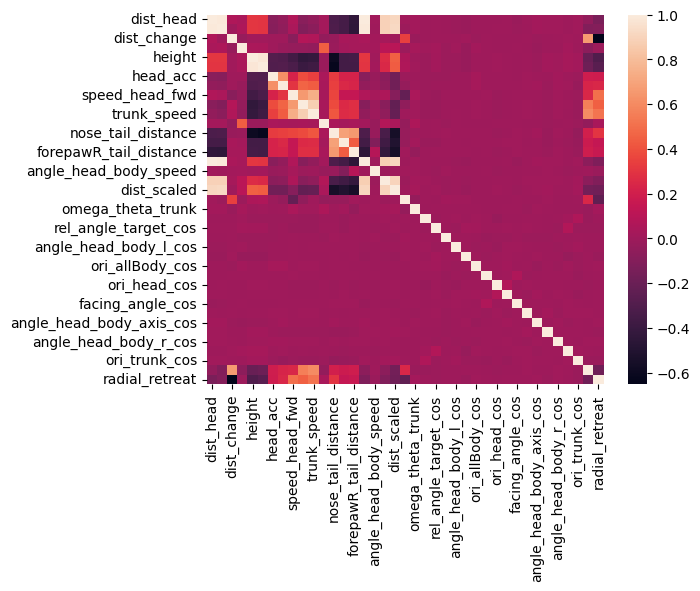

In [67]:
sns.heatmap(data_clean.corr())

Text(0, 0.5, 'cumulative variance')

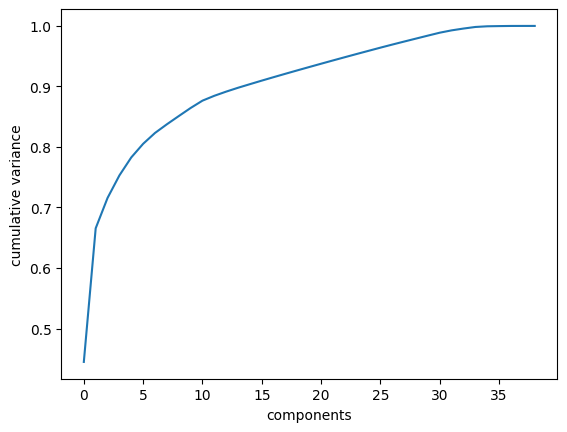

In [69]:
X = data_clean.dropna().values
pca = PCA()
Xp = pca.fit_transform(X)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("components")
plt.ylabel("cumulative variance")

In [70]:
fps = 60          
win_sec = 1.0
T = int(fps * win_sec)
stride = T // 2

X = data_clean.values
cols = data_clean.columns

windows = []

for start in range(0, len(X) - T + 1, stride):
    w = X[start:start+T]

    # mean
    mu = w.mean(axis=0)

    # std
    sd = w.std(axis=0)

    # linear slope per feature (captures trend)
    t = np.arange(T)
    slopes = np.polyfit(t, w, 1)[0]

    feat = np.concatenate([mu, sd, slopes])
    windows.append(feat)

windows = np.stack(windows)

# build dataframe
win_cols = (
    [c + "_mean" for c in cols] +
    [c + "_std" for c in cols] +
    [c + "_slope" for c in cols]
)

windows_df = pd.DataFrame(windows, columns=win_cols)

print("Windowed shape:", windows_df.shape)
windows_df.head()

Windowed shape: (2475, 117)


,dist_head_mean,dist_mean,dist_change_mean,rel_bearing_mean,height_mean,height_scaled_mean,head_acc_mean,rigidbody_acc_mean,speed_head_fwd_mean,head_speed_mean,...,facing_angle_sin_slope,facing_angle_cos_slope,angle_head_body_axis_sin_slope,angle_head_body_axis_cos_slope,angle_head_body_r_sin_slope,angle_head_body_r_cos_slope,ori_trunk_sin_slope,ori_trunk_cos_slope,radial_approach_slope,radial_retreat_slope
0,NaN,NaN,NaN,NaN,-0.419709,-0.373399,-0.095982,0.363181,0.789937,0.276540,...,NaN,NaN,0.000417,-0.002596,-0.003710,-0.011487,0.015882,-0.004439,NaN,NaN
1,NaN,NaN,NaN,NaN,-0.698902,-0.566632,-0.107063,0.309215,0.686825,0.184018,...,NaN,NaN,0.004917,-0.002210,0.013414,0.011091,-0.012334,0.010318,NaN,NaN
2,NaN,NaN,NaN,NaN,-0.953378,-0.761349,-0.276134,-0.231617,0.280596,-0.099502,...,NaN,NaN,0.005977,0.004992,0.009033,0.001938,0.019753,0.016574,NaN,NaN
3,NaN,NaN,NaN,NaN,-0.793292,-0.657349,-0.756129,-0.509448,-0.143468,-0.334976,...,NaN,NaN,-0.017884,0.011103,-0.018446,0.002868,-0.012479,0.008705,NaN,NaN
4,NaN,NaN,NaN,NaN,-0.754696,-0.632947,-0.620923,-0.239953,-0.177146,-0.300761,...,NaN,NaN,0.004873,0.000215,0.000994,-0.007069,-0.009438,0.002588,NaN,NaN


In [71]:
for c in windows_df.columns:
    windows_df[c] = robust_scale(windows_df[c])


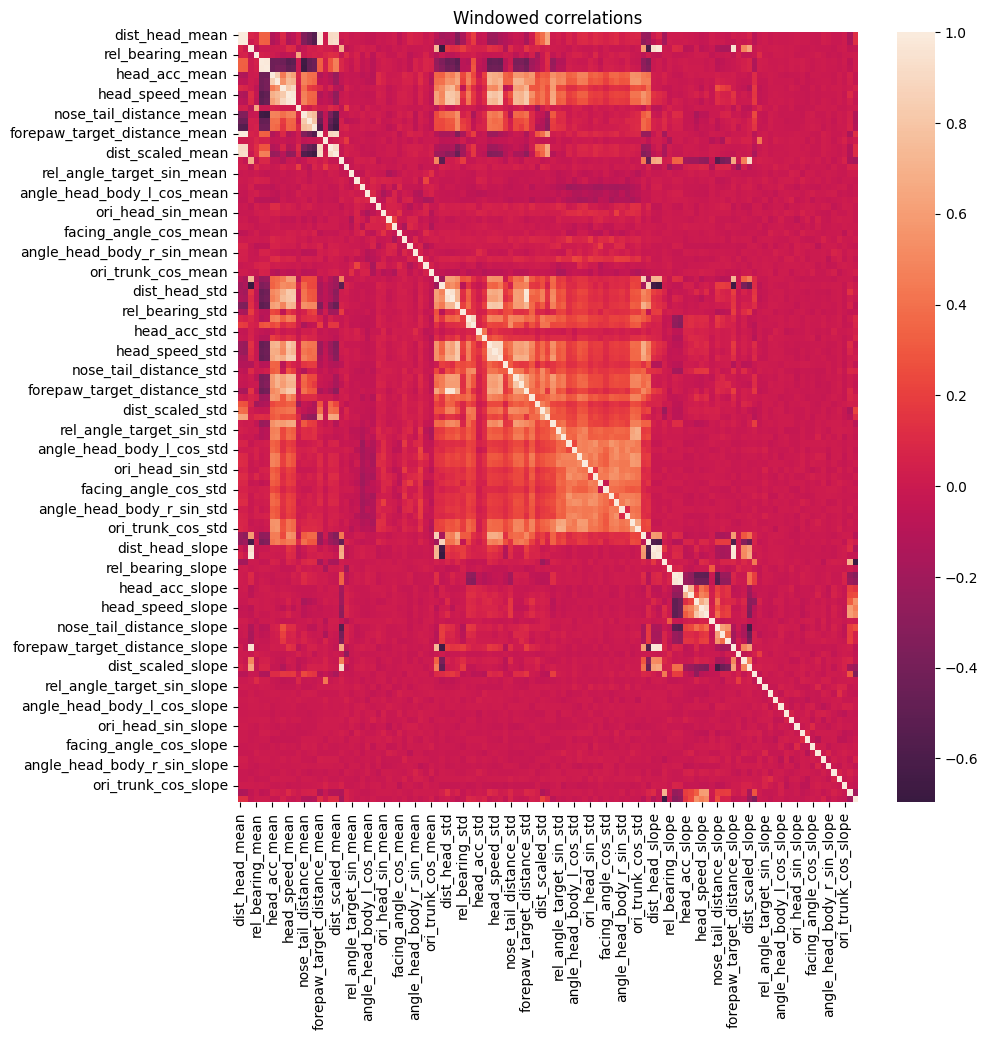

In [78]:
corr_win = windows_df.dropna().corr()


plt.figure(figsize=(10,10))
sns.heatmap(corr_win, cmap="rocket", center=0)
plt.title("Windowed correlations")
plt.show()


In [82]:
fps = 60        # CHANGE if needed
win_seconds = 1.0
T = int(fps * win_seconds)
stride = T // 2   # 50% overlap

# -------------------
# Build raw windows
# -------------------

X = data_clean.to_numpy(dtype=np.float32)   # (N, D)
feature_names = list(data_clean.columns)

N, D = X.shape
print("Frames:", N)
print("Features:", D)
print("Window length:", T)

windows = []
starts = []

for start in range(0, N - T + 1, stride):
    windows.append(X[start:start+T])
    starts.append(start)

X_windows = np.stack(windows)     # (W, T, D)
starts = np.array(starts)

print("Num windows:", X_windows.shape[0])
print("Tensor shape:", X_windows.shape)    # (W, T, D)

# -------------------
# Basic sanity checks
# -------------------

print("\nExample window (first 3 timesteps, first 5 features):")
print(X_windows[0, :3, :5])

print("\nFeature names:")
print(feature_names)

Frames: 74289
Features: 39
Window length: 60
Num windows: 2475
Tensor shape: (2475, 60, 39)

Example window (first 3 timesteps, first 5 features):
[[        nan         nan         nan         nan -0.63957584]
 [        nan         nan         nan         nan -0.65075797]
 [        nan         nan         nan         nan -0.6781794 ]]

Feature names:
['dist_head', 'dist', 'dist_change', 'rel_bearing', 'height', 'height_scaled', 'head_acc', 'rigidbody_acc', 'speed_head_fwd', 'head_speed', 'trunk_speed', 'tangential_vel', 'nose_tail_distance', 'forepawL_tail_distance', 'forepawR_tail_distance', 'forepaw_target_distance', 'angle_head_body_speed', 'dist_head_scaled', 'dist_scaled', 'dist_change_scaled', 'omega_theta_trunk', 'rel_angle_target_sin', 'rel_angle_target_cos', 'angle_head_body_l_sin', 'angle_head_body_l_cos', 'ori_allBody_sin', 'ori_allBody_cos', 'ori_head_sin', 'ori_head_cos', 'facing_angle_sin', 'facing_angle_cos', 'angle_head_body_axis_sin', 'angle_head_body_axis_cos', 'angle

In [83]:
keep = ["head_speed", "trunk_soeed", "dist_head", "notes_tail_distance", "radial_approach", "radial_retreat", "facing_angle_sin", "facing_angle_cos", "height_scaled"]
keep = [c for c in keep if c in data_clean.columns]  # only keep what exists
data_small = data_clean[keep].copy()

print("Using features:", data_small.columns.tolist())
print("Shape:", data_small.shape)

Using features: ['head_speed', 'dist_head', 'radial_approach', 'radial_retreat', 'facing_angle_sin', 'facing_angle_cos', 'height_scaled']
Shape: (74289, 7)


In [84]:
fps = 60
win_seconds = 1.0
T = int(fps * win_seconds)
stride = T // 2

X = data_small.to_numpy(dtype=np.float32)  # (N, D)
N, D = X.shape

windows = []
for start in range(0, N - T + 1, stride):
    windows.append(X[start:start+T])

X_windows = np.stack(windows)  # (W, T, D)
print("X_windows:", X_windows.shape)

X_windows: (2475, 60, 7)
